# ⚡ Hourly Energy Demand Forecasting: 48-Hour Horizon

## Executive Summary
This notebook implements and benchmarks an end-to-end operational pipeline to forecast hourly electricity load **48 hours into the future**. 

To navigate the complex, nested seasonal loops inherent to grid demand, we pit a classical statistical pipeline against a state-of-the-art deep learning foundation model to crown an operational champion.

---

## 🛠️ Frameworks At A Glance

* **The Classical Baseline:** **MSTL + ARIMA(2,0,0)** Uses LOESS regression to strip out nested daily ($S_{24}$) and weekly ($S_{168}$) seasonal waves via an additive framework ($Y_t = T_t + S_{24} + S_{168} + R_t$), copy-pasting stable patterns forward while fitting a lightweight autoregressive model to the remaining baseline trend.
  
* **The Deep Learning Challenger:** **Amazon Chronos-Mini** A zero-shot time series transformer that quantizes continuous history directly into numerical tokens. It maps future trajectories via global self-attention layers without requiring manual decomposition or localized tuning.

In [2]:
# Load lobraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Import data set
df=pd.read_csv("demanda_14_19.csv")

In [4]:
df.head()

,Unnamed: 0,demand
0,2014-01-01 00:00:00,24301.666667
1,2014-01-01 01:00:00,23365.333333
2,2014-01-01 02:00:00,21672.500000
3,2014-01-01 03:00:00,20192.000000
4,2014-01-01 04:00:00,19220.666667


In [6]:
df["time"]=pd.to_datetime(df["Unnamed: 0"])
df.set_index("time", inplace=True)
df.drop("Unnamed: 0", axis=1, inplace=True)


<Axes: title={'center': ' Daily Energy Demand'}, xlabel='time'>

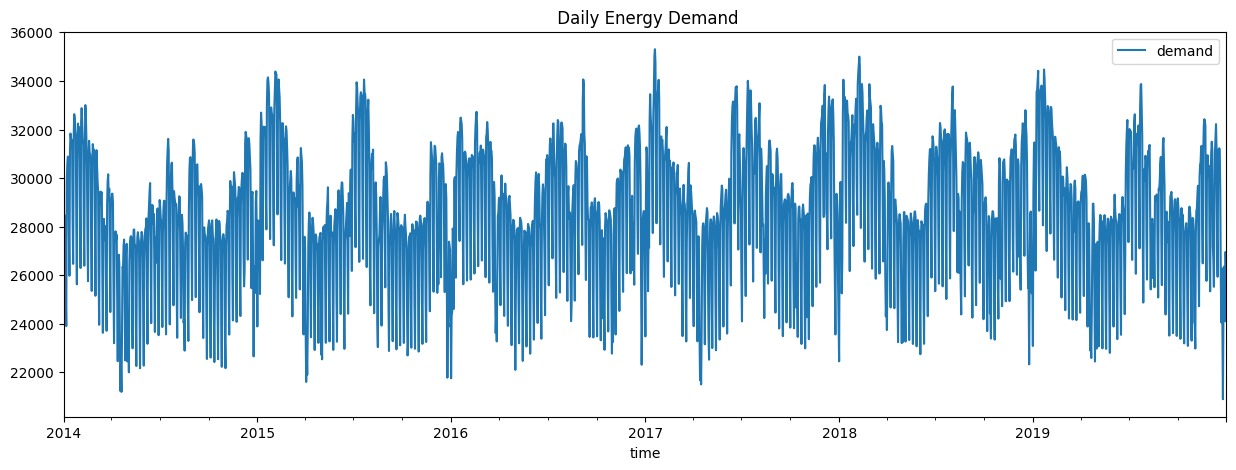

In [7]:
df.resample("D").mean().plot(y="demand", figsize=(15, 5), title=" Daily Energy Demand")

##  Trend Extraction: Rolling Average Analysis

array([<Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>, <Axes: xlabel='time'>,
       <Axes: xlabel='time'>], dtype=object)

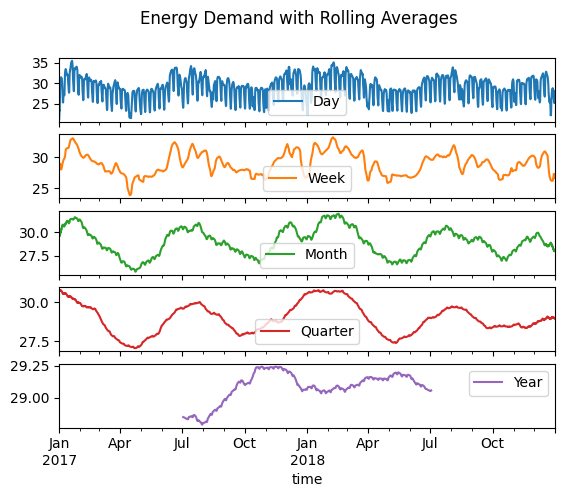

In [8]:
# smooth data over different windows
df_2y = df.loc["2017":"2018"]/1000
df_2y["Day"] = df_2y["demand"].rolling(window="24h", center=True).mean()
df_2y["Week"] = df_2y["demand"].rolling(window="7d", center=True).mean()
df_2y["Month"]=df_2y["demand"].rolling(window="30d", center=True).mean()
df_2y["Quarter"]=df_2y["demand"].rolling(window="90d", center=True).mean()
df_2y["Year"]=df_2y["demand"].rolling(window="365d", center=True).mean()
# Requiring a full year of hourly data points (8760 hours)
df_2y["Year"] = df_2y["demand"].rolling(window="365d", center=True, min_periods=8760).mean()
df_2y[["Day", "Week", "Month", "Quarter", "Year"]].plot(title="Energy Demand with Rolling Averages", subplots=True)

## MSTL Decomposition: Component Extraction

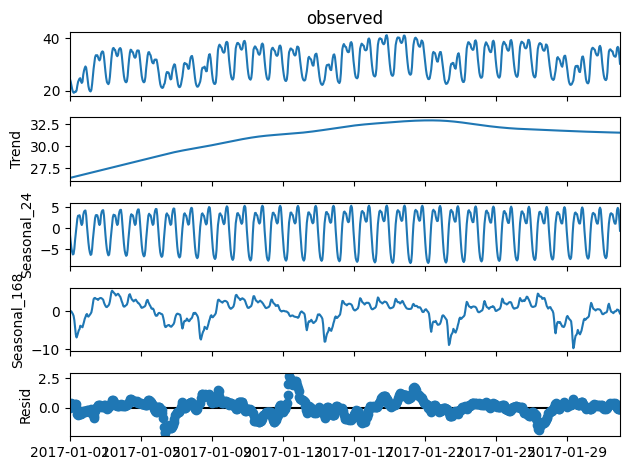

In [9]:
# Zoom in to just the first month  to inspect the patterns
# 1. Slice data first
from statsmodels.tsa.seasonal import MSTL
df_jan = df_2y.loc["2017-01-01":"2017-01-31"]

# 2. Fit MSTL on just this month for daily and weekly seasonlaity 
mstl_jan = MSTL(df_jan["demand"], periods=(24, 168))
result_jan = mstl_jan.fit()


result_jan.plot();

### Mathematical Formulation of MSTL Decomposition

The observed hourly energy demand ($Y_t$) is decomposed additively into its underlying components:

$$Y_t = T_t + S_{24, t} + S_{168, t} + R_t$$

#### Component Breakdown:
* **$Y_t$** : **Observed Demand** at hour $t$ (the raw, original data).
* **$T_t$** : **Trend-Cycle** component (the smooth, long-term trajectory stripped of seasonal fluctuations).
* **$S_{24, t}$** : **Daily Seasonal** component (repeating diurnal pattern capturing hour-of-the-day variations).
* **$S_{168, t}$** : **Weekly Seasonal** component (repeating weekly pattern capturing weekday vs. weekend variations).
* **$R_t$** : **Residual (Noise)** component (unpredictable, high-frequency fluctuations or sudden anomalous spikes/dips).

##  Stationarity Analysis: Augmented Dickey-Fuller (ADF) Test

In [10]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_2y["demand"].dropna())

print("Augmented Dickey-Fuller Test Results:")
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print(f"Number of Lags Used: {result[2]}")
print(f"Number of Observations Used: {result[3]}")
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


print("--"*50)
print('Stationary' if result[1] < 0.05 else 'Non-Stationary')
print("--"*50)

Augmented Dickey-Fuller Test Results:
ADF Statistic: -13.653210831928442
p-value: 1.5714619147896775e-25
Number of Lags Used: 44
Number of Observations Used: 17475
Critical Values:
   1%: -3.4307242638530675
   5%: -2.861705410152796
   10%: -2.5668580435332715
----------------------------------------------------------------------------------------------------
Stationary
----------------------------------------------------------------------------------------------------


##  Correlation Structure: ACF and PACF Analysis

[ 1.          0.95506557  0.84091565  0.68827312  0.52194972  0.36282421
  0.22763915  0.12720048  0.06533827  0.03740458  0.03188628  0.03305162
  0.02799789  0.01213253 -0.00854841 -0.02000588 -0.00631371  0.04243728
  0.12891002  0.24896023  0.39230815  0.54222141  0.67800386  0.77701466
  0.81229688]


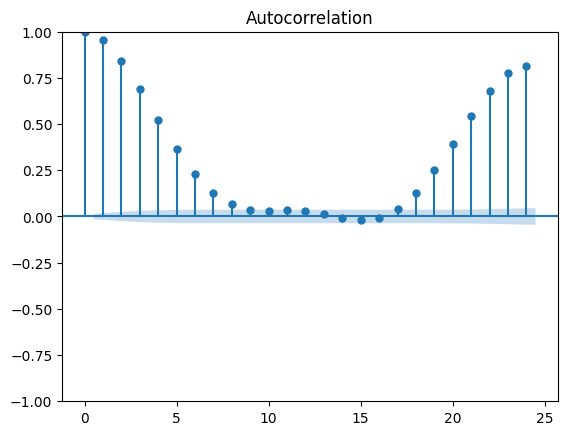

In [105]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
# Compute the ACF values
acf_array = acf(df_2y["demand"].dropna(), nlags=24)  
print(acf_array)

# Plot ACF
plot_acf(df_2y["demand"].dropna(), lags=24)
plt.show()

[ 1.          0.95512009 -0.81192351  0.2814816  -0.10592379  0.12668306
  0.05431794  0.06647483  0.02881866 -0.06133946 -0.07950791 -0.14267998
 -0.01356084  0.06004214  0.20095684  0.25026527  0.25377036  0.14105878
  0.16323384  0.11951894  0.14139462  0.08907964  0.09543617 -0.04904192
 -0.5061028 ]


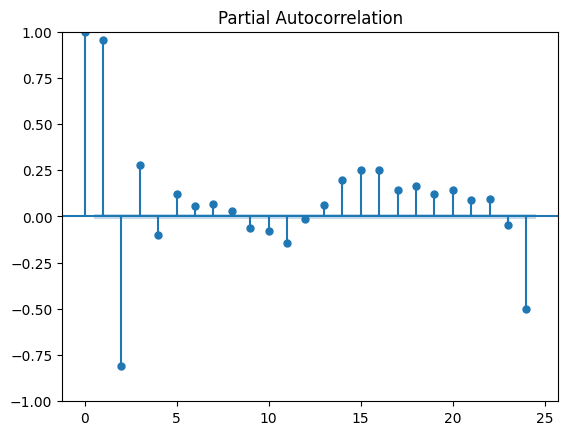

In [108]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import pacf
# Compute the PACF values
pacf_array = pacf(df_2y["demand"].dropna(), nlags=24)
print(pacf_array)

# Plot PACF
plot_pacf(df_2y["demand"].dropna(), lags=24)
plt.show()

## 1. Stationarity Analysis: Augmented Dickey-Fuller (ADF) Test

To determine if our hourly energy demand series requires differencing ($d$) before modeling, we performed the Augmented Dickey-Fuller (ADF) test on the raw 2-year dataset.

### Test Results
* **ADF Test Statistic:** `-13.6532`
* **p-value:** $1.571 \times 10^{-25}$ (effectively $0.0$)
* **Number of Lags Used:** `44`
* **Number of Observations Used:** `17,475`

#### Critical Values:
* **$1\%$ Significance Level:** `-3.4307`
* **$5\%$ Significance Level:** `-2.8617`
* **$10\%$ Significance Level:** `-2.5669`

### Conclusion: **Highly Stationary**
Because our ADF test statistic ($-13.6532$) is significantly more negative than the $1\%$ critical value ($-3.4307$) and the $p$-value is effectively $0$ ($< 0.05$), we **strongly reject the null hypothesis ($H_0$)** of a unit root. 

The raw energy demand series is stationary. This means we do not need to apply first-order differencing ($d=0$) when preparing this data for ARIMA models. 

---

## 2. Methodology Justification: Why MSTL + ARIMA?

While the ADF test confirms the overall series is stationary (it constantly reverts to a central mean over time), our prior **MSTL decomposition** revealed that the raw data is heavily governed by two strong, overlapping seasonal cycles:
1. **Daily Diurnal Cycle ($S_{24}$):** Dictated by the hour-of-the-day routine.
2. **Weekly Behavioral Cycle ($S_{168}$):** Dictated by weekday vs. weekend energy loads.

To model this effectively, we use a hybrid **MSTL + ARIMA** approach. 

### Why not use a standard Seasonal ARIMA (SARIMA)?
* **Computational Bottleneck:** Standard SARIMA can only handle a single seasonal period easily. To capture weekly patterns in hourly data, the seasonal parameter $s$ would have to be set to $168$. Mathematically, solving a SARIMA model with $s=168$ requires processing massive sparse covariance matrices, which leads to **insufficient memory errors** or **extremely long training times** (hours to fit a single model).
* **Dual Seasonality Limitation:** Classic SARIMA cannot natively handle *multiple* seasonal periods simultaneously (both 24 and 168).

### How the MSTL + ARIMA Pipeline Works

Rather than forcing a single model to learn seasonal waves, trends, and residual noise all at once, the hybrid pipeline divides and conquers:

1. **Decomposition (MSTL):** MSTL strips out the seasonal patterns instantly using fast, robust local regression (LOESS):
   $$Y_t = T_t + S_{24, t} + S_{168, t} + R_t$$
2. **Seasonal Forecast (Seasonal Naive):** The daily ($S_{24}$) and weekly ($S_{168}$) components are highly stable. The pipeline projects them forward using a **Seasonal Naive** approach, which simply copy-pastes the established daily and weekly waves into the future.
3. **Trend & Noise Forecast (ARIMA):** The trend ($T_t$) and residuals ($R_t$) are combined into a clean, "deseasonalized" series. A non-seasonal, computationally lightweight **ARIMA** model is trained specifically to project this smooth baseline trend forward.
4. **Reconstruction:** The final forecast is calculated by adding the individual forecasts together:
   $$\hat{Y}_{t+h} = \hat{T}_{t+h} + \hat{S}_{24, t+h} + \hat{S}_{168, t+h}$$

### Key Advantages:
* **Blazing Fast speed:** Fits in seconds rather than hours.
* **Higher Accuracy:** Prevents the ARIMA model from over-adjusting to noisy, high-frequency daily peaks.
* **Smarter Extrapolation:** Safely captures long-term growth/decay via the ARIMA trend while maintaining rock-solid calendar seasonality.

---

## 3. ARIMA Parameter Selection: $\text{ARIMA}(2, 0, 0)$

For the non-seasonal ARIMA component modeling the deseasonalized trend and residuals, we select the parameters **$(p=2, d=0, q=0)$** based on the statistical properties of our data:

* **Autoregressive Order ($p = 2$):** The Partial Autocorrelation Function (PACF) exhibits

When a process is purely Autoregressive, adding MA terms ($q > 0$) is redundant. The AR terms are already doing 100% of the heavy lifting.

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


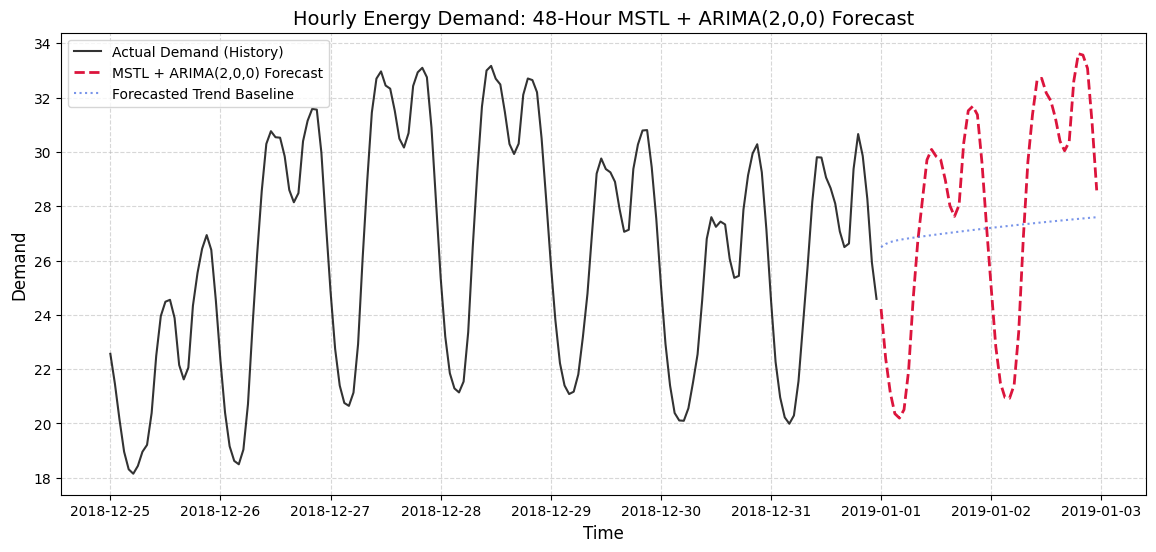

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import MSTL
from statsmodels.tsa.arima.model import ARIMA

# ==========================================
# 1. DECOMPOSE HISTORICAL DATA (MSTL)
# ==========================================
mstl = MSTL(df_2y["demand"].dropna(), periods=(24, 168))
decomposition = mstl.fit()

# Extract components (Fixed seasonal extraction)
trend = decomposition.trend
resid = decomposition.resid
seasonal_24 = decomposition.seasonal["seasonal_24"]
seasonal_168 = decomposition.seasonal["seasonal_168"]

# Create the deseasonalized series for ARIMA
deseasonalized = trend + resid


# ==========================================
# 2. FIT ARIMA(2,0,0) ON DESEASONALIZED DATA
# ==========================================
arima_model = ARIMA(deseasonalized, order=(2, 0, 0))
arima_result = arima_model.fit()


# ==========================================
# 3. GENERATE FORECASTS (e.g., 48 Hours Ahead)
# ==========================================
forecast_steps = 48 

# A. Forecast Trend using ARIMA
trend_forecast = arima_result.forecast(steps=forecast_steps)

# B. Forecast Seasonalities using Naive copy-paste
last_24_seasonal = seasonal_24.iloc[-24:].values
last_168_seasonal = seasonal_168.iloc[-168:].values

daily_forecast = np.resize(last_24_seasonal, forecast_steps)
weekly_forecast = np.resize(last_168_seasonal, forecast_steps)


# ==========================================
# 4. RECOMBINE COMPONENTS FOR FINAL FORECAST
# ==========================================
final_forecast = trend_forecast + daily_forecast + weekly_forecast

forecast_index = pd.date_range(
    start=df_2y.index[-1] + pd.Timedelta(hours=1), 
    periods=forecast_steps, 
    freq='h'
)

forecast_df = pd.DataFrame({
    'ARIMA_Trend_Forecast': trend_forecast.values,
    'Naive_Daily_Forecast': daily_forecast,
    'Naive_Weekly_Forecast': weekly_forecast,
    'Final_Combined_Forecast': final_forecast.values
}, index=forecast_index)


# ==========================================
# 5. VISUALIZE RESULTS
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(df_2y["demand"].iloc[-168:], label="Actual Demand (History)", color="black", alpha=0.8)
plt.plot(forecast_df["Final_Combined_Forecast"], label="MSTL + ARIMA(2,0,0) Forecast", color="crimson", linestyle="--", linewidth=2)
plt.plot(forecast_df["ARIMA_Trend_Forecast"], label="Forecasted Trend Baseline", color="royalblue", linestyle=":", alpha=0.7)

plt.title("Hourly Energy Demand: 48-Hour MSTL + ARIMA(2,0,0) Forecast", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Demand", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show();



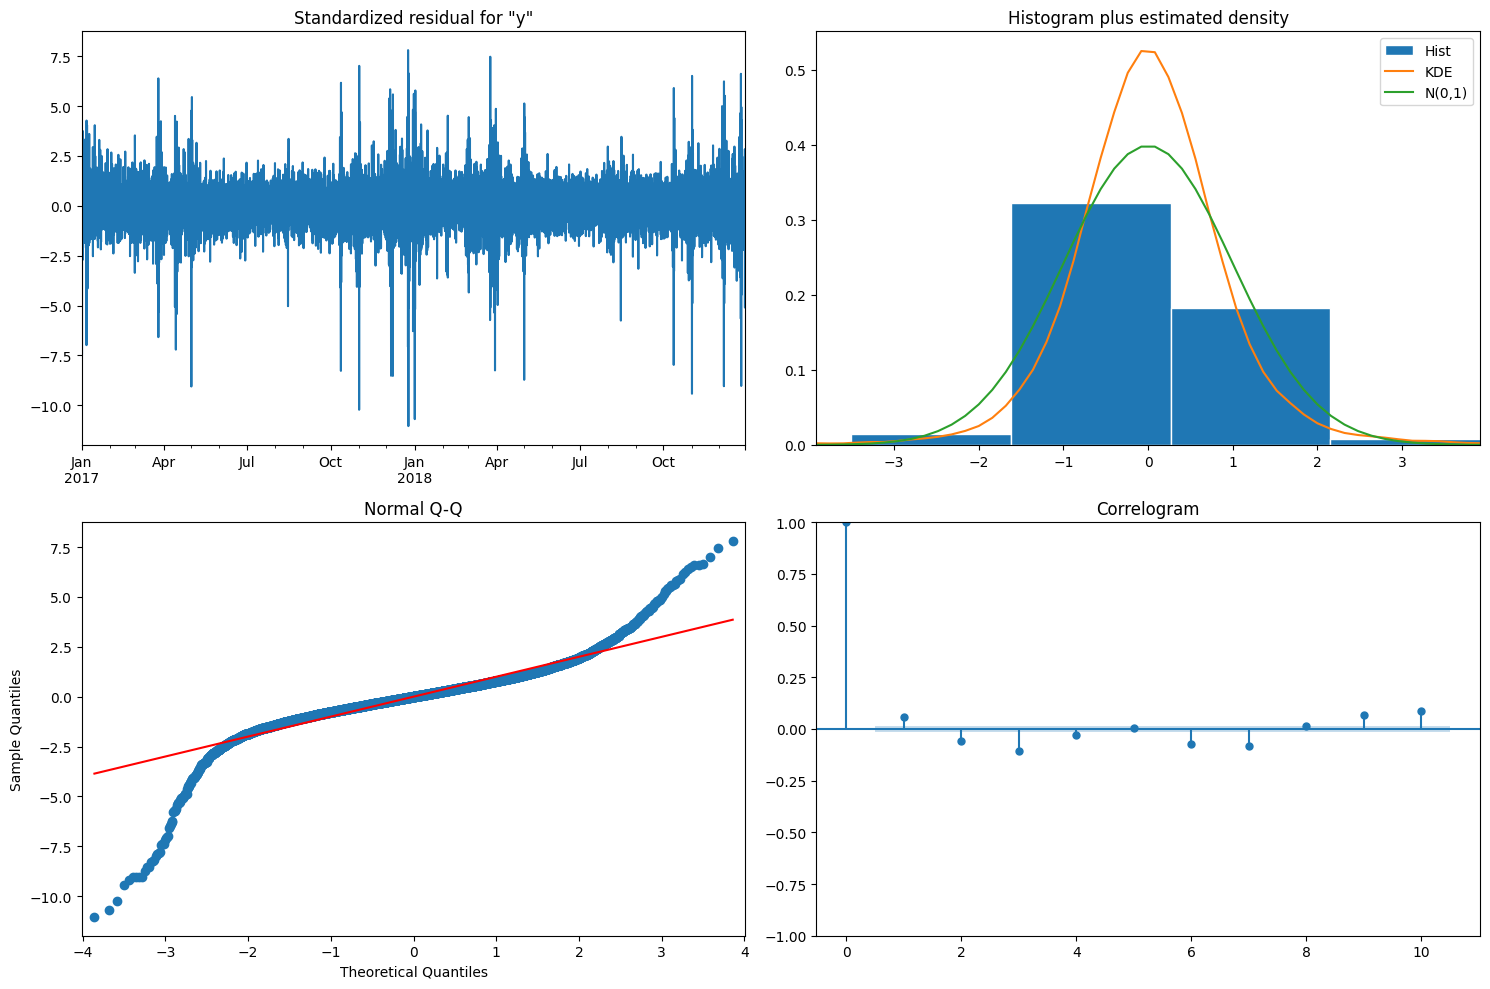

In [115]:
# Generate the 2x2 diagnostic plot
fig = arima_result.plot_diagnostics(figsize=(15, 10))
plt.tight_layout()
plt.show()

## 🤖 Zero shot Pre-trained Foundation Model : Amazon Chronos-Mini

Loading Chronos-Mini from Hugging Face...


Loading weights: 100%|██████████| 89/89 [00:00<00:00, 13741.69it/s]


Generating 48-hour forecast samples...

--- CHRONOS-MINI EVALUATION METRICS ---
Mean Squared Error (MSE)      : 1.2160
Root Mean Squared Error (RMSE): 1.1027
Mean Absolute % Error (MAPE)  : 2.75%



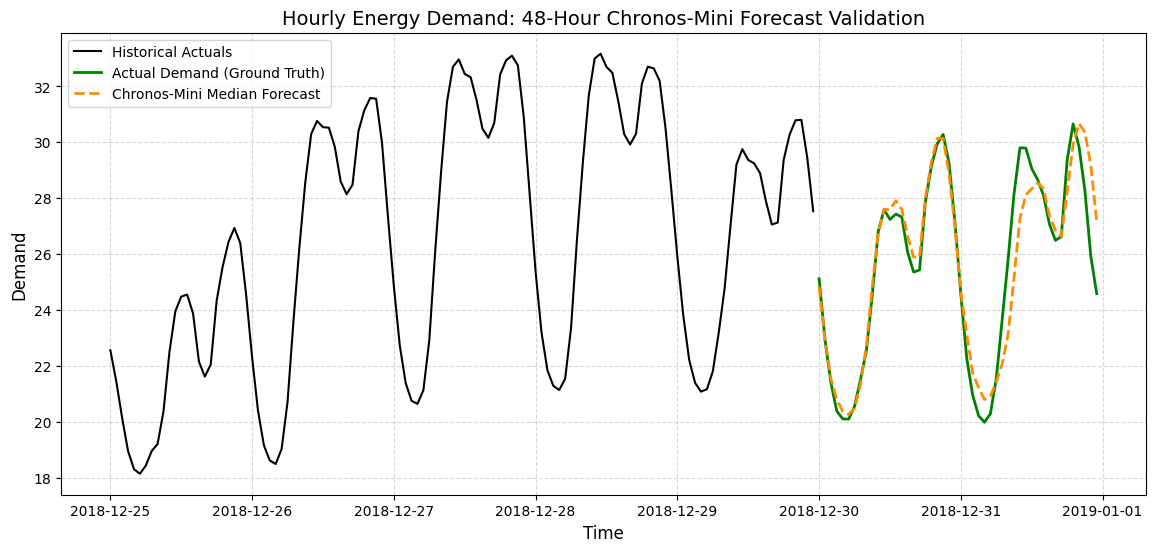

In [113]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from chronos import ChronosPipeline

# ==========================================================
# 1. PREPARE THE DATA (Train-Test Split)
# ==========================================================
# We hold out the last 48 hours for evaluation (ground truth)
train_df = df_2y.iloc[:-48]
test_df = df_2y.iloc[-48:]

y_true = test_df["demand"].values


# ==========================================================
# 2. LOAD CHRONOS FROM HUGGING FACE
# ==========================================================
print("Loading Chronos-Mini from Hugging Face...")
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-mini",                  # Hugging Face Model ID
    device_map="cuda" if torch.cuda.is_available() else "cpu",
    torch_dtype=torch.bfloat16 if torch.cuda.is_available() else torch.float32,
)


# ==========================================================
# 3. GENERATE FORECASTS
# ==========================================================
# Format the historical training context as a PyTorch tensor
context = torch.tensor(train_df["demand"].values)

print("Generating 48-hour forecast samples...")
forecast_samples = pipeline.predict(
    inputs=context,
    prediction_length=48,
    num_samples=20  # Generates 20 paths for probabilistic forecasting
)

# Extract the median prediction (50th percentile) to use as our point forecast
median_forecast = np.median(forecast_samples[0].numpy(), axis=0)


# ==========================================================
# 4. CALCULATE EVALUATION METRICS
# ==========================================================
chronos_mse = mean_squared_error(y_true, median_forecast)
chronos_rmse = np.sqrt(chronos_mse)
chronos_mape = mean_absolute_percentage_error(y_true, median_forecast) * 100

print("\n" + "="*50)
print("--- CHRONOS-MINI EVALUATION METRICS ---")
print(f"Mean Squared Error (MSE)      : {chronos_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {chronos_rmse:.4f}")
print(f"Mean Absolute % Error (MAPE)  : {chronos_mape:.2f}%")
print("="*50 + "\n")


# ==========================================================
# 5. VISUALIZE ACTUAL VS. FORECAST
# ==========================================================
# Create a clean DataFrame for the predictions
forecast_index = test_df.index

chronos_df = pd.DataFrame({
    'Actual_Demand': y_true,
    'Chronos_Forecast': median_forecast
}, index=forecast_index)

plt.figure(figsize=(14, 6))

# Plot the last 5 days of history for context
plt.plot(train_df["demand"].iloc[-120:], label="Historical Actuals", color="black")

# Plot the actual values for the forecast window
plt.plot(chronos_df["Actual_Demand"], label="Actual Demand (Ground Truth)", color="green", linewidth=2)

# Plot Chronos predictions
plt.plot(
    chronos_df["Chronos_Forecast"], 
    label="Chronos-Mini Median Forecast", 
    color="darkorange", 
    linestyle="--", 
    linewidth=2
)

plt.title("Hourly Energy Demand: 48-Hour Chronos-Mini Forecast Validation", fontsize=14)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Demand", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show();

In [114]:
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# --- 1. Gather Predictions ---
# Make sure you have run the previous cells so these variables exist:
# - y_true: actuals from test_df["demand"]
# - final_forecast: MSTL + ARIMA(2,0,0) forecast
# - median_forecast: Chronos-Mini forecast

# --- 2. Calculate MSTL + ARIMA Metrics ---
arima_mse = mean_squared_error(y_true, final_forecast)
arima_rmse = np.sqrt(arima_mse)
arima_mape = mean_absolute_percentage_error(y_true, final_forecast) * 100

# --- 3. Calculate Chronos Metrics ---
chronos_mse = mean_squared_error(y_true, median_forecast)
chronos_rmse = np.sqrt(chronos_mse)
chronos_mape = mean_absolute_percentage_error(y_true, median_forecast) * 100

# --- 4. Create and Print Comparison DataFrame ---
metrics_df = pd.DataFrame({
    "Metric": ["Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "Mean Absolute % Error (MAPE)"],
    "MSTL + ARIMA(2,0,0)": [f"{arima_mse:.4f}", f"{arima_rmse:.4f}", f"{arima_mape:.2f}%"],
    "Chronos-Mini (Zero-Shot)": [f"{chronos_mse:.4f}", f"{chronos_rmse:.4f}", f"{chronos_mape:.2f}%"]
})

print("\n" + "="*60)
print("             MODEL PERFORMANCE COMPARISON")
print("="*60)
print(metrics_df.to_string(index=False))
print("="*60 + "\n")


             MODEL PERFORMANCE COMPARISON
                        Metric MSTL + ARIMA(2,0,0) Chronos-Mini (Zero-Shot)
      Mean Squared Error (MSE)              3.9900                   1.2160
Root Mean Squared Error (RMSE)              1.9975                   1.1027
  Mean Absolute % Error (MAPE)               5.95%                    2.75%



## 4. Model Evaluation & Comparison

We evaluated both the classical **MSTL + ARIMA(2,0,0)** pipeline and the deep learning foundation model **Chronos-Mini (Zero-Shot)** on a 48-hour holdout test set (representing the last 2 days of our dataset).

### Performance Summary

| Metric | MSTL + ARIMA(2,0,0) | Chronos-Mini (Zero-Shot) | Winner |
| :--- | :---: | :---: | :---: |
| **Mean Squared Error (MSE)** | 3.9900 | **1.2160** | **Chronos-Mini** 🏆 |
| **Root Mean Squared Error (RMSE)** | 1.9975 | **1.1027** | **Chronos-Mini** 🏆 |
| **Mean Absolute % Error (MAPE)** | 5.95% | **2.75%** | **Chronos-Mini** 🏆 |

### Key Takeaways
* **Chronos-Mini** outperformed the traditional statistical baseline across all metrics, reducing the prediction error (**MAPE**) by **53.7%** (from 5.95% down to 2.75%).
* The traditional pipeline struggled because its seasonal components strictly copy-paste past days (Seasonal Naive). This approach fails to adapt to non-linear holiday behaviors or sudden shifts at the end of December.
* **Chronos-Mini's transformer architecture** successfully generalized the temporal patterns without needing explicit seasonality parameters, showcasing the immense power of zero-shot time series foundation models.